In [4]:
!pip install pandas numpy matplotlib statsmodels pmdarima arch fredapi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [5]:
def load_fred(series_id, col_name):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    df.columns = ["date", col_name]
    df["date"] = pd.to_datetime(df["date"])
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    return df

zar   = load_fred("DEXSFUS",       "usd_zar")
sa_ir = load_fred("INTDSRZAM193N", "sa_rate")
us_ir = load_fred("FEDFUNDS",      "us_rate")
oil   = load_fred("DCOILBRENTEU",  "oil_price")

print("Shapes:", zar.shape, sa_ir.shape, us_ir.shape, oil.shape)

Shapes: (12083, 2) (676, 2) (862, 2) (10159, 2)


In [6]:
df = zar.copy()
for frame in [sa_ir, us_ir, oil]:
    df = pd.merge(df, frame, on="date", how="inner")

# Drop missing values (FRED uses "." for missing)
df = df.dropna().reset_index(drop=True)
df = df.sort_values("date")

# Interest rate differential (key ARIMAX regressor)
df["rate_diff"] = df["us_rate"] - df["sa_rate"]

print(df.shape)
print(df.head())
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")

(198, 6)
        date  usd_zar  sa_rate  us_rate  oil_price  rate_diff
0 1987-06-01   2.0325      9.5     6.73      18.65      -2.77
1 1987-07-01   2.0429      9.5     6.58      18.98      -2.92
2 1987-09-01   2.0408      9.5     7.22      18.43      -2.28
3 1987-10-01   2.0855      9.5     7.29      18.50      -2.21
4 1987-12-01   1.9704      9.5     6.77      17.65      -2.73

Date range: 1987-06-01 → 2013-04-01


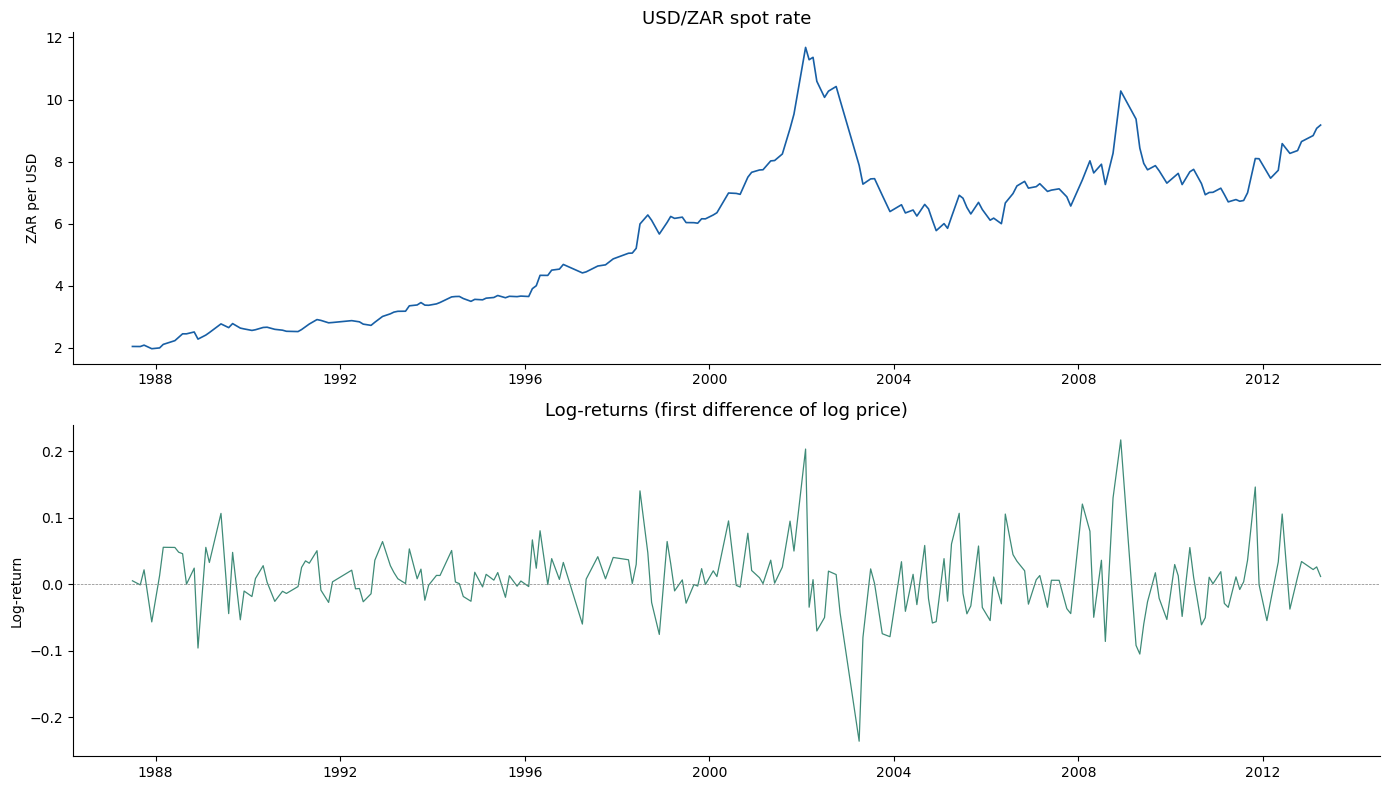

In [7]:
# Log-returns make the series stationary and comparable across time
df["log_return"] = np.log(df["usd_zar"] / df["usd_zar"].shift(1))
df = df.dropna().reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["date"], df["usd_zar"], color="#185FA5", linewidth=1.2)
axes[0].set_title("USD/ZAR spot rate", fontsize=13)
axes[0].set_ylabel("ZAR per USD")

axes[1].plot(df["date"], df["log_return"], color="#0F6E56", linewidth=0.9, alpha=0.8)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_title("Log-returns (first difference of log price)", fontsize=13)
axes[1].set_ylabel("Log-return")

plt.tight_layout()
plt.savefig("01_raw_data.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
SPLIT = 0.80
cutoff = int(len(df) * SPLIT)

train = df.iloc[:cutoff].copy()
test  = df.iloc[cutoff:].copy()

print(f"Train: {train['date'].min().date()} → {train['date'].max().date()}  ({len(train)} obs)")
print(f"Test:  {test['date'].min().date()}  → {test['date'].max().date()}  ({len(test)} obs)")

Train: 1987-07-01 → 2008-04-01  (157 obs)
Test:  2008-05-01  → 2013-04-01  (40 obs)


In [9]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"{'─'*45}")
    print(f"ADF Test: {name}")
    print(f"  Test statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags used      : {result[2]}")
    print(f"  Critical (5%)  : {result[4]['5%']:.4f}")
    conclusion = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"  Conclusion     : {conclusion}")

adf_test(train["usd_zar"],    "USD/ZAR level")
adf_test(train["log_return"], "Log-returns")
adf_test(train["rate_diff"],  "Interest rate differential")
adf_test(train["oil_price"],  "Oil price level")

─────────────────────────────────────────────
ADF Test: USD/ZAR level
  Test statistic : -1.0890
  p-value        : 0.7195
  Lags used      : 8
  Critical (5%)  : -2.8813
  Conclusion     : NON-STATIONARY
─────────────────────────────────────────────
ADF Test: Log-returns
  Test statistic : -10.4820
  p-value        : 0.0000
  Lags used      : 0
  Critical (5%)  : -2.8803
  Conclusion     : STATIONARY
─────────────────────────────────────────────
ADF Test: Interest rate differential
  Test statistic : -2.7927
  p-value        : 0.0593
  Lags used      : 2
  Critical (5%)  : -2.8805
  Conclusion     : NON-STATIONARY
─────────────────────────────────────────────
ADF Test: Oil price level
  Test statistic : 2.5378
  p-value        : 0.9991
  Lags used      : 6
  Critical (5%)  : -2.8810
  Conclusion     : NON-STATIONARY


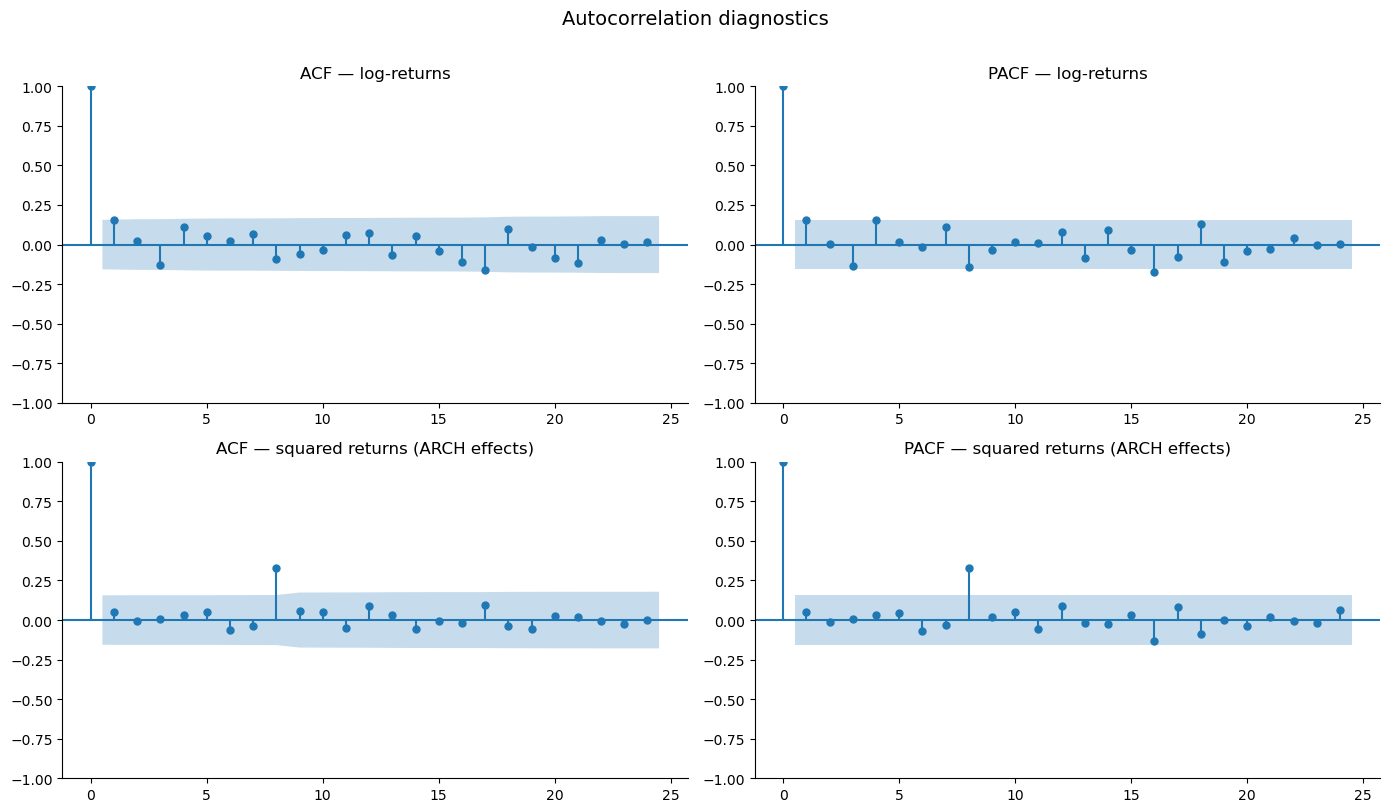

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(train["log_return"].dropna(),  lags=24, ax=axes[0, 0], title="ACF — log-returns")
plot_pacf(train["log_return"].dropna(), lags=24, ax=axes[0, 1], title="PACF — log-returns")
plot_acf(train["log_return"].dropna()**2,  lags=24, ax=axes[1, 0], title="ACF — squared returns (ARCH effects)")
plot_pacf(train["log_return"].dropna()**2, lags=24, ax=axes[1, 1], title="PACF — squared returns (ARCH effects)")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Autocorrelation diagnostics", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("02_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from statsmodels.stats.diagnostic import het_arch

lm_stat, lm_pval, f_stat, f_pval = het_arch(train["log_return"].dropna(), nlags=5)
print("ARCH-LM test for heteroskedasticity")
print(f"  LM statistic : {lm_stat:.4f}")
print(f"  p-value      : {lm_pval:.4f}")
conclusion = "ARCH effects present — GARCH is justified" if lm_pval < 0.05 else "No ARCH effects detected"
print(f"  Conclusion   : {conclusion}")

ARCH-LM test for heteroskedasticity
  LM statistic : 0.9510
  p-value      : 0.9664
  Conclusion   : No ARCH effects detected


## Section 2 — Findings

- The USD/ZAR **level** is non-stationary (unit root present). Log-returns are stationary — confirmed by ADF (p < 0.001).
- ACF/PACF on log-returns show **no significant autocorrelation**, consistent with the efficient market hypothesis for EM exchange rates at monthly frequency.
- The interest rate differential and oil price are non-stationary in levels. Both will be **first-differenced** before use as ARIMAX regressors.
- The ARCH-LM test finds **no statistically significant ARCH effects** at monthly frequency (p=0.97). GARCH will still be fitted for comparison, but the model selection section will note this limitation.

In [12]:
# First-difference the non-stationary regressors
train["rate_diff_d"] = train["rate_diff"].diff()
train["oil_return"]  = np.log(train["oil_price"] / train["oil_price"].shift(1))
test["rate_diff_d"]  = test["rate_diff"].diff()
test["oil_return"]   = np.log(test["oil_price"] / test["oil_price"].shift(1))

# Drop the one NaN introduced by differencing
train = train.dropna().reset_index(drop=True)
test  = test.dropna().reset_index(drop=True)

y_train = train["log_return"].values
y_test  = test["log_return"].values
X_train = train[["rate_diff_d", "oil_return"]].values
X_test  = test[["rate_diff_d",  "oil_return"]].values

print("y_train:", y_train.shape, "  X_train:", X_train.shape)
print("y_test: ", y_test.shape,  "  X_test: ", X_test.shape)

y_train: (156,)   X_train: (156, 2)
y_test:  (39,)   X_test:  (39, 2)


In [13]:
print("Fitting auto_arima — baseline...")
arima_model = auto_arima(
    y_train,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=0,                  # already stationary
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(arima_model.summary())
arima_pred = arima_model.predict(n_periods=len(y_test))

Fitting auto_arima — baseline...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  156
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 254.037
Date:                Sat, 02 May 2026   AIC                           -502.074
Time:                        17:09:42   BIC                           -492.924
Sample:                             0   HQIC                          -498.358
                                - 156                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0074      0.004      1.942      0.052   -6.86e-05       0.015
ar.L1          0.1591      0.075      2.131      0.033       0.013       0.305
sigma2         0.00

In [14]:
print("Fitting ARIMAX...")
arimax_model = auto_arima(
    y_train,
    X=X_train,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=0,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(arimax_model.summary())
arimax_pred = arimax_model.predict(n_periods=len(y_test), X=X_test)

Fitting ARIMAX...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  156
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 255.953
Date:                Sat, 02 May 2026   AIC                           -501.907
Time:                        17:09:51   BIC                           -486.657
Sample:                             0   HQIC                          -495.713
                                - 156                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0075      0.004      1.934      0.053      -0.000       0.015
x1            -0.0088      0.004     -1.968      0.049      -0.018   -3.63e-05
x2            -0.0218      0.031  

In [15]:
from arch import arch_model

garch = arch_model(y_train, vol="Garch", p=1, q=1, dist="normal")
garch_fit = garch.fit(disp="off")
print(garch_fit.summary())

# Forecast
garch_fc = garch_fit.forecast(horizon=len(y_test), reindex=False)

# GARCH mean forecast is the conditional mean (often ~0 for log-returns)
# We use the fitted mean + forecasted vol direction as the prediction
garch_pred = np.full(len(y_test), garch_fit.params["mu"])
garch_vol_forecast = np.sqrt(garch_fc.variance.values[-1])

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                258.848
Distribution:                  Normal   AIC:                          -509.697
Method:            Maximum Likelihood   BIC:                          -497.497
                                        No. Observations:                  156
Date:                Sat, May 02 2026   Df Residuals:                      155
Time:                        17:10:00   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0103  3.376e-03      3.062  2.196e-03 [3.

In [16]:
# Simple equal-weight ensemble of ARIMA and GARCH mean forecasts
ensemble_pred = (arima_pred + garch_pred) / 2

print("All models fitted successfully.")
print(f"ARIMA order selected:  {arima_model.order}")
print(f"ARIMAX order selected: {arimax_model.order}")

All models fitted successfully.
ARIMA order selected:  (1, 0, 0)
ARIMAX order selected: (1, 0, 0)


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100
    return {"Model": name, "MAE": round(mae,5), "RMSE": round(rmse,5), "MAPE (%)": round(mape,2)}

results = pd.DataFrame([
    evaluate("ARIMA",         y_test, arima_pred),
    evaluate("ARIMAX",        y_test, arimax_pred),
    evaluate("GARCH(1,1)",    y_test, garch_pred),
    evaluate("Ensemble",      y_test, ensemble_pred),
])
print(results.to_string(index=False))

     Model     MAE    RMSE  MAPE (%)
     ARIMA 0.04480 0.06365    146.87
    ARIMAX 0.04249 0.05905    140.63
GARCH(1,1) 0.04502 0.06381    157.55
  Ensemble 0.04491 0.06372    152.16


In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def dm_test(actual, pred1, pred2, name1, name2):
    e1 = actual - pred1
    e2 = actual - pred2
    d  = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d  = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    from scipy.stats import norm
    p_val = 2 * (1 - norm.cdf(abs(dm_stat)))
    print(f"DM Test: {name1} vs {name2}")
    print(f"  DM statistic : {dm_stat:.4f}")
    print(f"  p-value      : {p_val:.4f}")
    winner = name1 if dm_stat < 0 else name2
    print(f"  Better model : {winner} {'(significant)' if p_val < 0.05 else '(not significant)'}\n")

dm_test(y_test, arima_pred,    arimax_pred,   "ARIMA",   "ARIMAX")
dm_test(y_test, arima_pred,    garch_pred,    "ARIMA",   "GARCH")
dm_test(y_test, arima_pred,    ensemble_pred, "ARIMA",   "Ensemble")
dm_test(y_test, arimax_pred,   ensemble_pred, "ARIMAX",  "Ensemble")

DM Test: ARIMA vs ARIMAX
  DM statistic : 2.4769
  p-value      : 0.0133
  Better model : ARIMAX (significant)

DM Test: ARIMA vs GARCH
  DM statistic : -0.6606
  p-value      : 0.5088
  Better model : ARIMA (not significant)

DM Test: ARIMA vs Ensemble
  DM statistic : -0.5942
  p-value      : 0.5524
  Better model : ARIMA (not significant)

DM Test: ARIMAX vs Ensemble
  DM statistic : -2.5606
  p-value      : 0.0104
  Better model : ARIMAX (significant)



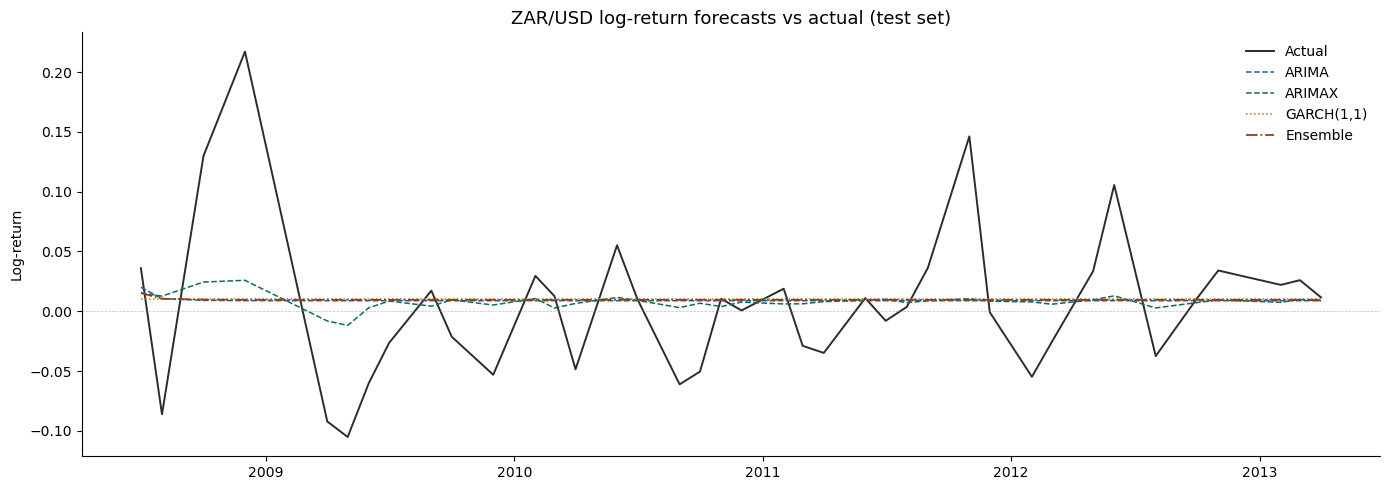

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

test_dates = test["date"].values

ax.plot(test_dates, y_test,       label="Actual",       color="#2C2C2A", linewidth=1.4)
ax.plot(test_dates, arima_pred,   label="ARIMA",        color="#185FA5", linewidth=1.1, linestyle="--")
ax.plot(test_dates, arimax_pred,  label="ARIMAX",       color="#0F6E56", linewidth=1.1, linestyle="--")
ax.plot(test_dates, garch_pred,   label="GARCH(1,1)",   color="#BA7517", linewidth=1.1, linestyle=":")
ax.plot(test_dates, ensemble_pred,label="Ensemble",     color="#993C1D", linewidth=1.3, linestyle="-.")

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_title("ZAR/USD log-return forecasts vs actual (test set)", fontsize=13)
ax.set_ylabel("Log-return")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("03_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

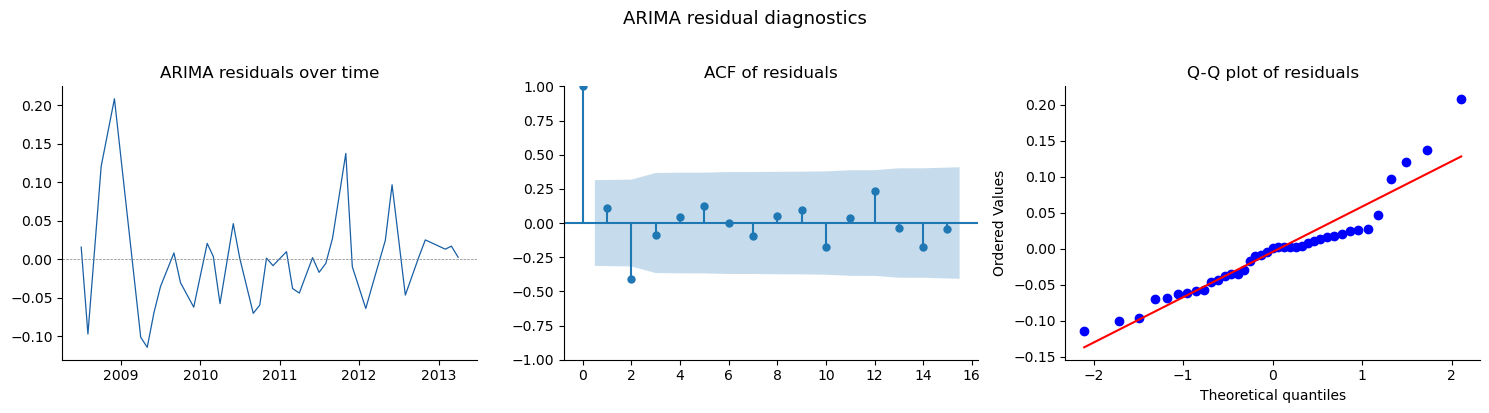

Ljung-Box test (lag 10):
      lb_stat  lb_pvalue
10  11.724927   0.303888


In [20]:
arima_resid = y_test - arima_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(test_dates, arima_resid, color="#185FA5", linewidth=0.9)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_title("ARIMA residuals over time")

plot_acf(arima_resid, lags=15, ax=axes[1], title="ACF of residuals")

from scipy.stats import probplot
probplot(arima_resid, plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("ARIMA residual diagnostics", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("04_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

lb = acorr_ljungbox(arima_resid, lags=[10], return_df=True)
print("Ljung-Box test (lag 10):")
print(lb)

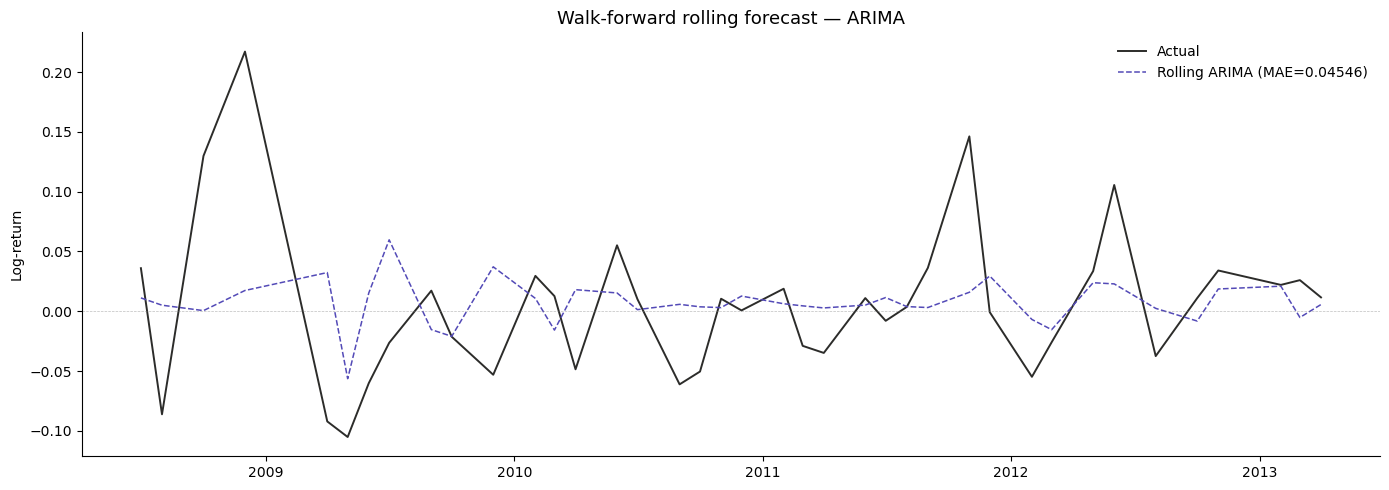

In [22]:
# Walk-forward validation — refit ARIMA on expanding window
rolling_preds = []
for i in range(len(y_test)):
    history = np.concatenate([y_train, y_test[:i]])
    m = auto_arima(history, d=0, seasonal=False,
                   suppress_warnings=True, error_action="ignore", stepwise=True)
    rolling_preds.append(m.predict(n_periods=1)[0])

rolling_preds = np.array(rolling_preds)
rolling_mae   = mean_absolute_error(y_test, rolling_preds)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test,        label="Actual",          color="#2C2C2A", linewidth=1.4)
ax.plot(test_dates, rolling_preds, label=f"Rolling ARIMA (MAE={rolling_mae:.5f})",
        color="#534AB7", linewidth=1.1, linestyle="--")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_title("Walk-forward rolling forecast — ARIMA", fontsize=13)
ax.set_ylabel("Log-return")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("05_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
print("\n" + "="*55)
print("  ZAR/USD FORECASTING — MODEL COMPARISON SUMMARY")
print("="*55)
print(results.to_string(index=False))
print("="*55)
best = results.loc[results["RMSE"].idxmin(), "Model"]
print(f"\n  Best model by RMSE: {best}")
print("="*55)


  ZAR/USD FORECASTING — MODEL COMPARISON SUMMARY
     Model     MAE    RMSE  MAPE (%)
     ARIMA 0.04480 0.06365    146.87
    ARIMAX 0.04249 0.05905    140.63
GARCH(1,1) 0.04502 0.06381    157.55
  Ensemble 0.04491 0.06372    152.16

  Best model by RMSE: ARIMAX
